# 04 — DeepLOB-Attention Extension & Ablation Study

This notebook evaluates the **DeepLOB-Attention** extension — replacing LSTM with a Transformer
encoder — against the original DeepLOB and all baselines on the FI-2010 dataset
(Setup 2, DecPre normalization) across all 5 prediction horizons (k=10, 20, 30, 50, 100).

**Extension** (trained via `scripts/train_extension.py` on Amarel HPC):
- **DeepLOB-Attention** — CNN + Inception (identical to DeepLOB) + Transformer encoder (replaces LSTM)

**Ablation variants** (to isolate component contributions):
- **CNN-Only** — CNN blocks only, no Inception, no temporal modeling
- **CNN+Attention** — CNN blocks + Transformer, no Inception

---

###  Background: Why Replace LSTM with Attention?

**LSTM limitations for LOB prediction:**
- Processes tokens **sequentially** — information from timestep 1 must pass through all 105
  intermediate states to reach timestep 106. Long-range dependencies get diluted.
- The hidden state is a **fixed-size bottleneck** (64 dimensions in DeepLOB). All temporal
  information must be compressed into this small vector.
- Cannot be parallelized across timesteps during training.

**Self-attention advantages:**
- Computes **direct pairwise interactions** between ALL timesteps simultaneously.
  Timestep 106 can attend directly to timestep 1 without information passing through 105 states.
- No fixed bottleneck — the representation at each position is d_model=192 dimensions.
- Fully parallelizable across timesteps.

**Trade-off:**
- Attention is O(L²·d) vs LSTM's O(L·d²). With our L=106 and d=192, attention is efficient.
- More parameters (~597K vs 144K) — risk of overfitting with limited training data.
- Transformers need lower learning rates and warmup for stable training.

###  Architecture Comparison

| Component | DeepLOB | DeepLOB-Attention |
|-----------|---------|------------------|
| CNN Block 1 (price+volume) |  Same |  Same |
| CNN Block 2 (ask+bid) |  Same |  Same |
| CNN Block 3 (level integration) |  Same |  Same |
| Inception Module |  Same |  Same |
| **Temporal Modeling** | **LSTM (64 hidden)** | **2× Transformer Encoder (d=192, 4 heads)** |
| Pooling | Last timestep | Mean pool over sequence |
| Parameters | ~144K | ~597K |
| Training LR | 0.01, eps=1.0 | 0.001, eps=1e-8, 5-epoch warmup |

### Contents
1. Load saved results (no Amarel access needed)
2. Accuracy comparison table: all models × all horizons
3. Weighted F1 comparison table
4. Accuracy comparison bar chart
5. DeepLOB-Attention confusion matrices
6. Training curve comparison
7. Ablation analysis: component contribution
8. Parameter efficiency analysis
9. Classification reports
10. Discussion and study questions


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

PROJECT_ROOT = Path(".").resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

sns.set_theme(style="whitegrid", font_scale=1.1)
%matplotlib inline

HORIZONS = [10, 20, 30, 50, 100]
CLASS_NAMES = ["Down", "Stationary", "Up"]
EXTENSION_DIR = PROJECT_ROOT / "experiments" / "extension"
BASELINES_DIR = PROJECT_ROOT / "experiments" / "baselines"

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/tt/Individual Projects/deeplob-project


## 1. Load Saved Results

All results loaded from saved `.pt` files — no Amarel access needed.

 **Study note — What's in each history.pt:**
- `test_accuracy`, `test_f1_weighted`: Final metrics on the test set
- `test_predictions`, `test_labels`: Raw predictions for confusion matrices
- `train_loss`, `val_loss`, etc.: Per-epoch training curves
- `best_epoch`: When early stopping chose the best model

In [2]:
# Load DeepLOB-Attention (extension) results
extension = {}
print("DeepLOB-Attention results:")
for h in HORIZONS:
    path = EXTENSION_DIR / f"k{h}" / "history.pt"
    if path.exists():
        data = torch.load(path, map_location="cpu", weights_only=False)
        extension[h] = data
        f1_str = f", F1={data['test_f1_weighted']*100:.2f}%" if 'test_f1_weighted' in data else ""
        print(f"  k={h:3d}: acc={data['test_accuracy']*100:.2f}%{f1_str}, "
              f"best_epoch={data['best_epoch']}, epochs={len(data['train_loss'])}")
    else:
        print(f"  k={h:3d}: NOT FOUND at {path}")
        print(f"         → Run training on Amarel first, then scp results to experiments/extension/k{h}/")

DeepLOB-Attention results:
  k= 10: acc=82.44%, F1=81.07%, best_epoch=22, epochs=42
  k= 20: acc=71.49%, F1=67.66%, best_epoch=33, epochs=53
  k= 30: acc=76.93%, F1=76.32%, best_epoch=15, epochs=35
  k= 50: acc=79.21%, F1=79.11%, best_epoch=11, epochs=31
  k=100: acc=78.77%, F1=78.82%, best_epoch=8, epochs=28


In [3]:
# Load DeepLOB (original) results
deeplob = {}
print("DeepLOB (original) results:")
for h in HORIZONS:
    history = torch.load(
        PROJECT_ROOT / "experiments" / f"k{h}" / "history.pt",
        map_location="cpu", weights_only=False,
    )
    deeplob[h] = history
    print(f"  k={h:3d}: acc={history['test_accuracy']*100:.2f}%, best_epoch={history['best_epoch']}")

DeepLOB (original) results:
  k= 10: acc=81.88%, best_epoch=26
  k= 20: acc=73.77%, best_epoch=15
  k= 30: acc=76.14%, best_epoch=14
  k= 50: acc=77.34%, best_epoch=18
  k=100: acc=78.19%, best_epoch=12


In [4]:
# Load baseline results
baseline_names = ["logistic_regression", "mlp", "xgboost"]
display_names = {"logistic_regression": "LogReg", "mlp": "MLP", "xgboost": "XGBoost"}

baselines = {}
for name in baseline_names:
    baselines[name] = {}
    for h in HORIZONS:
        data = torch.load(BASELINES_DIR / f"{name}_k{h}.pt", weights_only=False)
        baselines[name][h] = data

print("Baseline results loaded (LogReg, MLP, XGBoost)")

Baseline results loaded (LogReg, MLP, XGBoost)


In [5]:
# Load ablation variant results (CNN-Only and CNN+Attention)
ABLATION_DIR = PROJECT_ROOT / "experiments" / "ablation"

ablation = {}
for variant, display in [("cnn_only", "CNN-Only"), ("cnn_attention", "CNN+Attention")]:
    ablation[variant] = {}
    print(f"\n{display} results:")
    for h in HORIZONS:
        path = ABLATION_DIR / variant / f"k{h}" / "history.pt"
        if path.exists():
            data = torch.load(path, map_location="cpu", weights_only=False)
            ablation[variant][h] = data
            f1_str = f", F1={data['test_f1_weighted']*100:.2f}%" if 'test_f1_weighted' in data else ""
            print(f"  k={h:3d}: acc={data['test_accuracy']*100:.2f}%{f1_str}, "
                  f"best_epoch={data['best_epoch']}, epochs={len(data['train_loss'])}")
        else:
            print(f"  k={h:3d}: NOT FOUND at {path}")


CNN-Only results:
  k= 10: acc=83.53%, F1=82.21%, best_epoch=20, epochs=40
  k= 20: acc=74.96%, F1=72.74%, best_epoch=18, epochs=38
  k= 30: acc=76.30%, F1=75.84%, best_epoch=19, epochs=39
  k= 50: acc=78.14%, F1=78.12%, best_epoch=13, epochs=33
  k=100: acc=77.71%, F1=77.78%, best_epoch=9, epochs=29

CNN+Attention results:
  k= 10: acc=83.84%, F1=82.81%, best_epoch=20, epochs=40
  k= 20: acc=75.22%, F1=73.51%, best_epoch=11, epochs=31
  k= 30: acc=77.46%, F1=76.87%, best_epoch=17, epochs=37
  k= 50: acc=78.97%, F1=78.86%, best_epoch=14, epochs=34
  k=100: acc=79.41%, F1=79.47%, best_epoch=10, epochs=30


## 2. Accuracy Comparison Table

 **Study note — Reading the comparison:**
- **"Δ vs LSTM"** = DeepLOB-Attention accuracy minus DeepLOB accuracy.
  Positive means the Transformer extension improved over the LSTM.
- We expect the improvement to be largest at longer horizons (k=50, k=100)
  where temporal dependencies span more timesteps and attention's direct
  pairwise connections should help most.

In [6]:
if extension:
    rows = []
    for h in HORIZONS:
        dl_acc = deeplob[h]["test_accuracy"] * 100
        row = {
            "Horizon": f"k={h}",
            "DeepLOB": f"{dl_acc:.2f}",
        }
        if h in extension:
            ext_acc = extension[h]["test_accuracy"] * 100
            delta = ext_acc - dl_acc
            row["DL-Attention"] = f"{ext_acc:.2f}"
            row["Δ vs LSTM"] = f"{delta:+.2f}"
        else:
            row["DL-Attention"] = "—"
            row["Δ vs LSTM"] = "—"
        row["XGBoost"] = f"{baselines['xgboost'][h]['accuracy']*100:.2f}"
        row["LogReg"] = f"{baselines['logistic_regression'][h]['accuracy']*100:.2f}"
        rows.append(row)

    df_acc = pd.DataFrame(rows)
    print("Test Accuracy (%) — All Models x All Horizons")
    print("=" * 75)
    print(df_acc.to_string(index=False))
    print("\nΔ vs LSTM = DL-Attention - DeepLOB (positive = attention wins)")
else:
    print("No extension results found. Train on Amarel first.")

Test Accuracy (%) — All Models x All Horizons
Horizon DeepLOB DL-Attention Δ vs LSTM XGBoost LogReg
   k=10   81.88        82.44     +0.56   80.16  72.20
   k=20   73.77        71.49     -2.28   71.99  63.67
   k=30   76.14        76.93     +0.79   72.89  57.90
   k=50   77.34        79.21     +1.87   71.82  50.23
  k=100   78.19        78.77     +0.58   66.53  47.62

Δ vs LSTM = DL-Attention - DeepLOB (positive = attention wins)


## 3. Weighted F1 Comparison Table

In [7]:
if extension:
    f1_rows = []
    for h in HORIZONS:
        row = {"Horizon": f"k={h}"}
        # DeepLOB F1 (may not be available for original runs)
        dl_f1 = deeplob[h].get("test_f1_weighted")
        row["DeepLOB"] = f"{dl_f1*100:.2f}" if dl_f1 else "—"
        # Extension F1
        if h in extension and "test_f1_weighted" in extension[h]:
            row["DL-Attention"] = f"{extension[h]['test_f1_weighted']*100:.2f}"
        else:
            row["DL-Attention"] = "—"
        # Baselines
        row["XGBoost"] = f"{baselines['xgboost'][h]['f1_weighted']*100:.2f}"
        row["LogReg"] = f"{baselines['logistic_regression'][h]['f1_weighted']*100:.2f}"
        f1_rows.append(row)

    df_f1 = pd.DataFrame(f1_rows)
    print("Weighted F1 (%) — All Models x All Horizons")
    print("=" * 65)
    print(df_f1.to_string(index=False))
else:
    print("No extension results found.")

Weighted F1 (%) — All Models x All Horizons
Horizon DeepLOB DL-Attention XGBoost LogReg
   k=10       —        81.07   77.45  62.79
   k=20       —        67.66   68.20  54.56
   k=30       —        76.32   71.12  53.63
   k=50       —        79.11   71.38  50.40
  k=100       —        78.82   66.54  40.58


## 4. Accuracy Comparison Bar Chart

 **Study note — What to look for:**
- DeepLOB-Attention (red) vs DeepLOB (blue): Does replacing LSTM with attention help?
- Both should be taller than XGBoost (purple) across all horizons.
- The gap between deep learning models and baselines should grow with horizon.

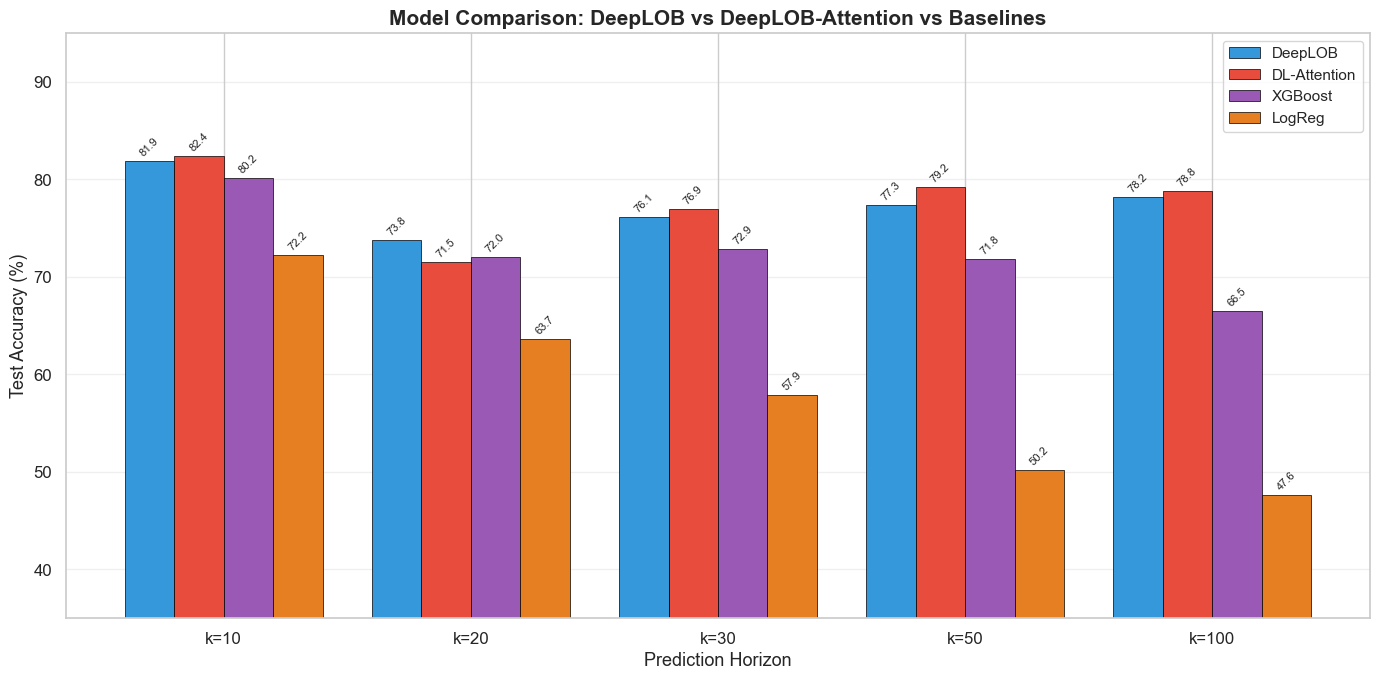

Saved to experiments/extension/accuracy_comparison.png


In [8]:
if extension:
    fig, ax = plt.subplots(figsize=(14, 7))

    model_labels = ["DeepLOB", "DL-Attention", "XGBoost", "LogReg"]
    colors = ["#3498db", "#e74c3c", "#9b59b6", "#e67e22"]
    x = np.arange(len(HORIZONS))
    width = 0.2

    all_accs = {
        "DeepLOB": [deeplob[h]["test_accuracy"] * 100 for h in HORIZONS],
        "DL-Attention": [extension[h]["test_accuracy"] * 100 if h in extension else 0 for h in HORIZONS],
        "XGBoost": [baselines["xgboost"][h]["accuracy"] * 100 for h in HORIZONS],
        "LogReg": [baselines["logistic_regression"][h]["accuracy"] * 100 for h in HORIZONS],
    }

    for i, (name, color) in enumerate(zip(model_labels, colors)):
        bars = ax.bar(
            x + (i - 1.5) * width, all_accs[name], width,
            label=name, color=color, edgecolor="black", linewidth=0.5,
        )
        for bar in bars:
            if bar.get_height() > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                    f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8, rotation=45,
                )

    ax.set_xlabel("Prediction Horizon", fontsize=13)
    ax.set_ylabel("Test Accuracy (%)", fontsize=13)
    ax.set_title("Model Comparison: DeepLOB vs DeepLOB-Attention vs Baselines", fontsize=15, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([f"k={h}" for h in HORIZONS])
    ax.set_ylim(35, 95)
    ax.legend(fontsize=11)
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    EXTENSION_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(EXTENSION_DIR / "accuracy_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to experiments/extension/accuracy_comparison.png")
else:
    print("No extension results found.")

## 5. DeepLOB-Attention Confusion Matrices

 **Study note — What to look for in confusion matrices:**
- **Diagonal dominance** = model predicts correctly most of the time.
- Compare with DeepLOB: does attention improve recall for minority classes (Down, Up)?
- At k=10, the "Stationary" class dominates (70.7%). A good model should still predict
  some Down/Up rather than collapsing to majority class.

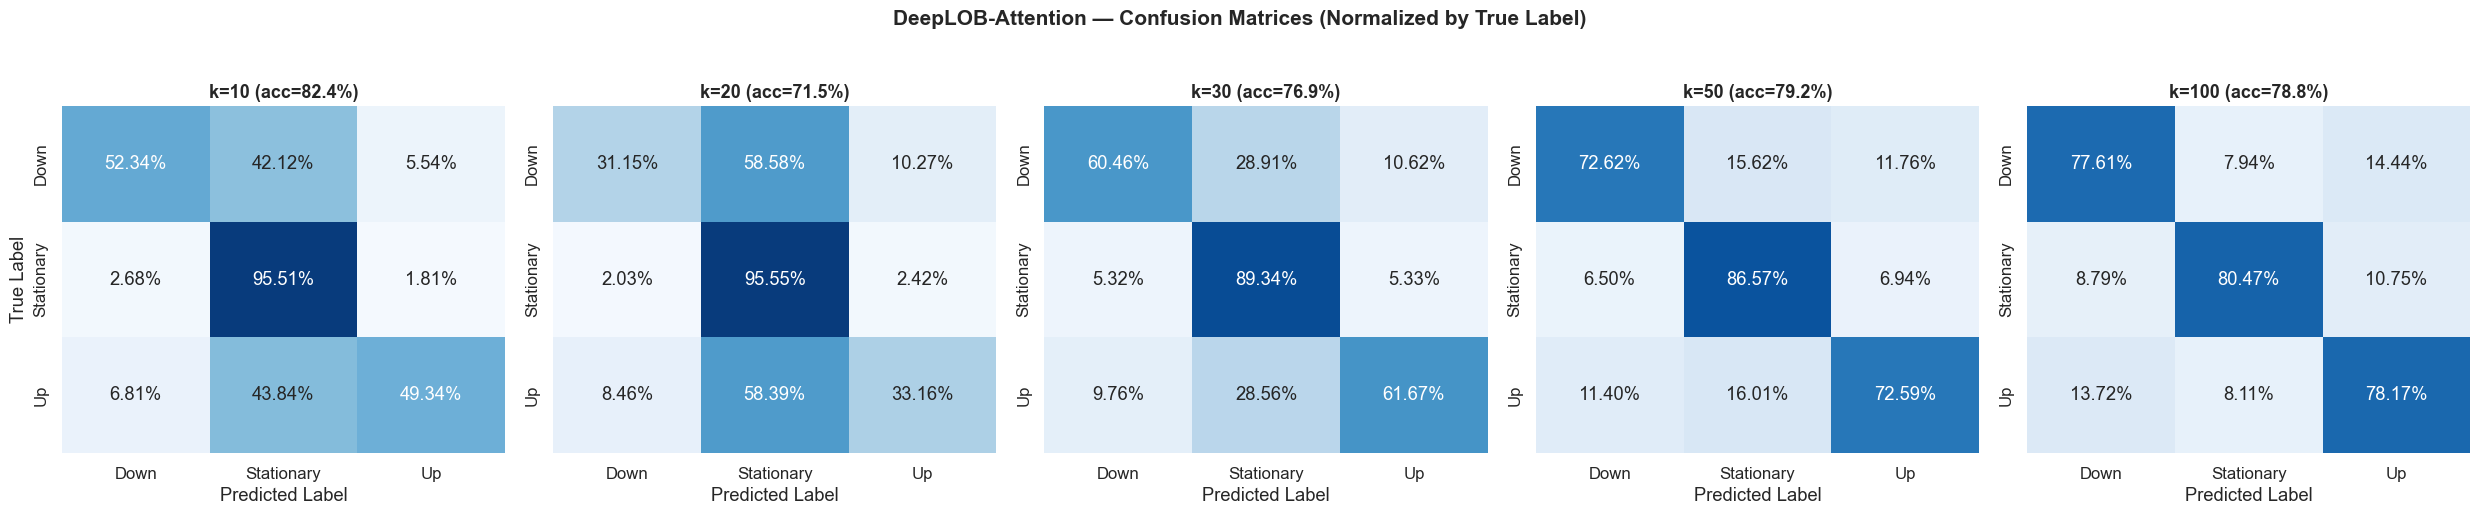

Saved to experiments/extension/confusion_matrices_attention.png


In [9]:
available_ext = [h for h in HORIZONS if h in extension and "test_predictions" in extension[h]]

if available_ext:
    n = len(available_ext)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, h in zip(axes, available_ext):
        preds = extension[h]["test_predictions"].numpy()
        labels = extension[h]["test_labels"].numpy()
        cm = confusion_matrix(labels, preds)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        sns.heatmap(
            cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, vmin=0, vmax=1, cbar=False,
        )
        acc = accuracy_score(labels, preds)
        ax.set_title(f"k={h} (acc={acc*100:.1f}%)", fontsize=13, fontweight="bold")
        ax.set_ylabel("True Label" if h == available_ext[0] else "")
        ax.set_xlabel("Predicted Label")

    fig.suptitle(
        "DeepLOB-Attention — Confusion Matrices (Normalized by True Label)",
        fontsize=15, fontweight="bold", y=1.03,
    )
    plt.tight_layout()
    plt.savefig(EXTENSION_DIR / "confusion_matrices_attention.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to experiments/extension/confusion_matrices_attention.png")
else:
    print("No test predictions available in extension results.")

## 6. Training Curve Comparison

 **Study note — What to look for in training curves:**
- **Convergence speed**: Does attention converge faster or slower than LSTM?
  Transformers often converge faster once past the warmup phase.
- **Overfitting gap**: Distance between train and val curves. A larger gap
  means the model memorizes training data instead of learning general patterns.
  With ~597K params (vs 144K), the attention model may overfit more.
- **Warmup effect**: The first 5 epochs should show gradually increasing
  learning rate — look for a slow start in the attention model's train loss.

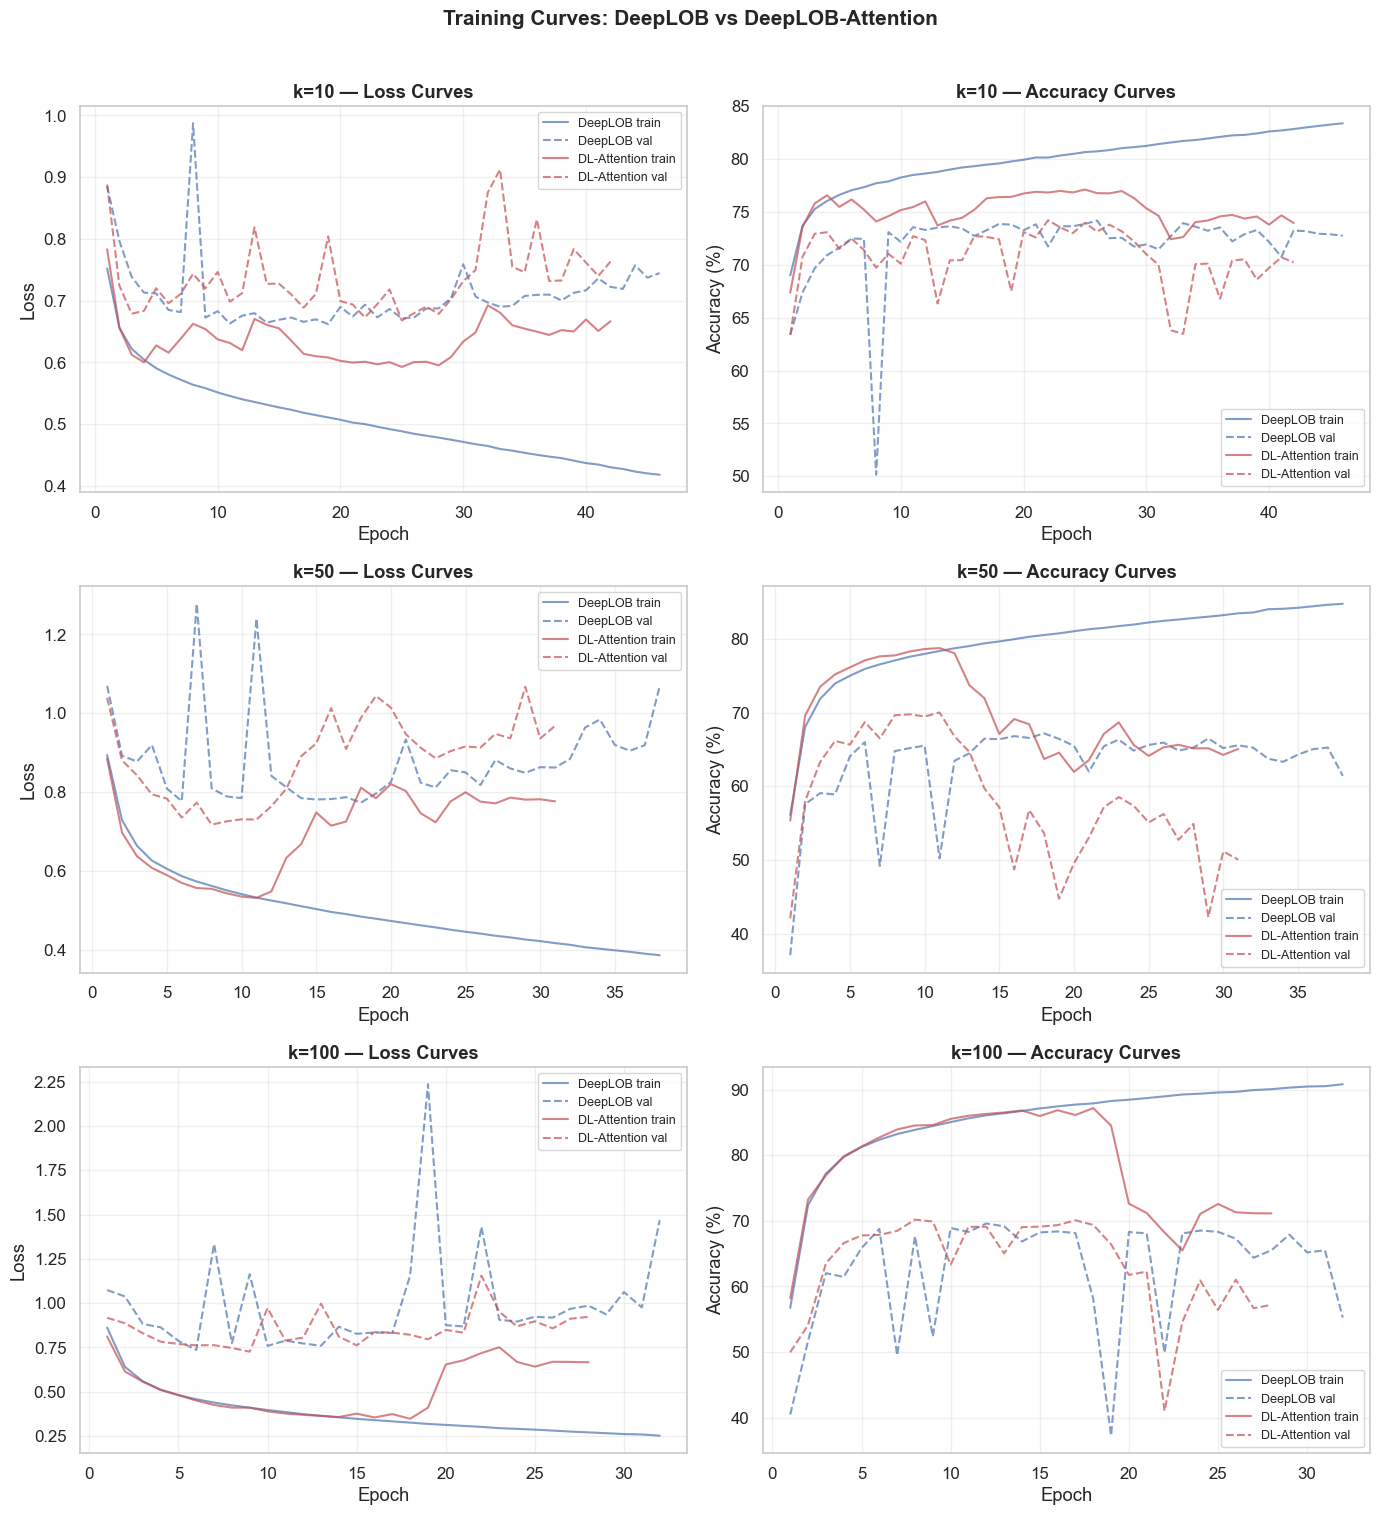

Saved to experiments/extension/training_curves_comparison.png


In [10]:
# Compare training curves for a representative horizon
comparison_horizons = [h for h in [10, 50, 100] if h in extension]

if comparison_horizons:
    fig, axes = plt.subplots(len(comparison_horizons), 2, figsize=(14, 5 * len(comparison_horizons)))
    if len(comparison_horizons) == 1:
        axes = axes.reshape(1, -1)

    for row, h in enumerate(comparison_horizons):
        # Loss curves
        ax = axes[row, 0]
        dl_epochs = range(1, len(deeplob[h]["train_loss"]) + 1)
        ext_epochs = range(1, len(extension[h]["train_loss"]) + 1)

        ax.plot(dl_epochs, deeplob[h]["train_loss"], "b-", alpha=0.7, label="DeepLOB train")
        ax.plot(dl_epochs, deeplob[h]["val_loss"], "b--", alpha=0.7, label="DeepLOB val")
        ax.plot(ext_epochs, extension[h]["train_loss"], "r-", alpha=0.7, label="DL-Attention train")
        ax.plot(ext_epochs, extension[h]["val_loss"], "r--", alpha=0.7, label="DL-Attention val")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.set_title(f"k={h} — Loss Curves", fontweight="bold")
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

        # Accuracy curves
        ax = axes[row, 1]
        ax.plot(dl_epochs, [a * 100 for a in deeplob[h]["train_accuracy"]], "b-", alpha=0.7, label="DeepLOB train")
        ax.plot(dl_epochs, [a * 100 for a in deeplob[h]["val_accuracy"]], "b--", alpha=0.7, label="DeepLOB val")
        ax.plot(ext_epochs, [a * 100 for a in extension[h]["train_accuracy"]], "r-", alpha=0.7, label="DL-Attention train")
        ax.plot(ext_epochs, [a * 100 for a in extension[h]["val_accuracy"]], "r--", alpha=0.7, label="DL-Attention val")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy (%)")
        ax.set_title(f"k={h} — Accuracy Curves", fontweight="bold")
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

    plt.suptitle("Training Curves: DeepLOB vs DeepLOB-Attention", fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(EXTENSION_DIR / "training_curves_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to experiments/extension/training_curves_comparison.png")
else:
    print("No extension results available for training curve comparison.")

## 7. Ablation Analysis

 **Study note — What is an ablation study?**
- Systematically **remove components** from a model to measure each one's contribution.
- If removing a component barely hurts accuracy, that component isn't pulling its weight.
- We test 4 variants with increasing complexity:
  1. **CNN-Only** (~1.2K params): CNN blocks → Global Avg Pool → FC
  2. **CNN+Attention** (~67K params): CNN blocks → Transformer(d=32) → FC
  3. **DeepLOB** (~144K params): CNN blocks → Inception → LSTM → FC
  4. **DL-Attention** (~597K params): CNN blocks → Inception → Transformer(d=192) → FC

In [11]:
# Full ablation comparison — ordered by architectural complexity
# CNN-Only < CNN+Attn < DeepLOB (CNN+Inc+LSTM) < DL-Attention (CNN+Inc+Attn)

rows = []
for h in HORIZONS:
    row = {"Horizon": f"k={h}"}

    # Ablation variants
    if "cnn_only" in ablation and h in ablation["cnn_only"]:
        row["CNN-Only"] = f"{ablation['cnn_only'][h]['test_accuracy'] * 100:.2f}"
    else:
        row["CNN-Only"] = "—"

    if "cnn_attention" in ablation and h in ablation["cnn_attention"]:
        row["CNN+Attn"] = f"{ablation['cnn_attention'][h]['test_accuracy'] * 100:.2f}"
    else:
        row["CNN+Attn"] = "—"

    # Full models
    row["DeepLOB"] = f"{deeplob[h]['test_accuracy'] * 100:.2f}"

    if h in extension:
        row["DL-Attn"] = f"{extension[h]['test_accuracy'] * 100:.2f}"
    else:
        row["DL-Attn"] = "—"

    # Baselines for reference
    row["XGBoost"] = f"{baselines['xgboost'][h]['accuracy'] * 100:.2f}"

    rows.append(row)

df_ablation = pd.DataFrame(rows)
print("Ablation Study — Test Accuracy (%) by Architectural Complexity")
print("=" * 80)
print(df_ablation.to_string(index=False))
print()
print("Architecture ladder (left to right = more complex):")
print("  CNN-Only:   CNN blocks 1-3 → Global Avg Pool → FC  (~1K params)")
print("  CNN+Attn:   CNN blocks 1-3 → Transformer(d=32) → FC  (~67K params)")
print("  DeepLOB:    CNN blocks 1-3 → Inception → LSTM → FC  (~144K params)")
print("  DL-Attn:    CNN blocks 1-3 → Inception → Transformer(d=192) → FC  (~597K params)")

Ablation Study — Test Accuracy (%) by Architectural Complexity
Horizon CNN-Only CNN+Attn DeepLOB DL-Attn XGBoost
   k=10    83.53    83.84   81.88   82.44   80.16
   k=20    74.96    75.22   73.77   71.49   71.99
   k=30    76.30    77.46   76.14   76.93   72.89
   k=50    78.14    78.97   77.34   79.21   71.82
  k=100    77.71    79.41   78.19   78.77   66.53

Architecture ladder (left to right = more complex):
  CNN-Only:   CNN blocks 1-3 → Global Avg Pool → FC  (~1K params)
  CNN+Attn:   CNN blocks 1-3 → Transformer(d=32) → FC  (~67K params)
  DeepLOB:    CNN blocks 1-3 → Inception → LSTM → FC  (~144K params)
  DL-Attn:    CNN blocks 1-3 → Inception → Transformer(d=192) → FC  (~597K params)


In [12]:
# Component contribution analysis with real ablation data
has_ablation = "cnn_only" in ablation and "cnn_attention" in ablation

if has_ablation and all(h in ablation["cnn_only"] and h in ablation["cnn_attention"] for h in HORIZONS):
    print("Component Contribution Analysis")
    print("=" * 90)
    print(f"{'Horizon':>8s}  {'CNN-Only':>10s}  {'+ Attn':>10s}  {'+ Inc+LSTM':>12s}  {'+ Inc+Attn':>12s}  {'Attn Δ':>8s}  {'Inc+LSTM Δ':>10s}")
    print("-" * 90)

    attn_deltas = []
    inc_deltas = []
    cnn_wins_vs_dl = 0

    for h in HORIZONS:
        cnn = ablation["cnn_only"][h]["test_accuracy"] * 100
        cnn_attn = ablation["cnn_attention"][h]["test_accuracy"] * 100
        dl = deeplob[h]["test_accuracy"] * 100
        ext = extension[h]["test_accuracy"] * 100 if h in extension else None

        # What does adding attention (without Inception) do?
        attn_delta = cnn_attn - cnn
        attn_deltas.append(attn_delta)

        # What does adding Inception+LSTM do vs CNN-Only?
        inc_delta = dl - cnn
        inc_deltas.append(inc_delta)

        if cnn > dl:
            cnn_wins_vs_dl += 1

        ext_str = f"{ext:10.2f}%" if ext else "         —"
        print(f"  k={h:3d}    {cnn:8.2f}%  {cnn_attn:8.2f}%    {dl:10.2f}%  {ext_str}  {attn_delta:+6.2f}pp  {inc_delta:+8.2f}pp")

    print("-" * 90)
    avg_cnn = np.mean([ablation["cnn_only"][h]["test_accuracy"] * 100 for h in HORIZONS])
    avg_cnn_attn = np.mean([ablation["cnn_attention"][h]["test_accuracy"] * 100 for h in HORIZONS])
    avg_dl = np.mean([deeplob[h]["test_accuracy"] * 100 for h in HORIZONS])
    avg_ext = np.mean([extension[h]["test_accuracy"] * 100 for h in HORIZONS])
    print(f"  {'Avg':>5s}    {avg_cnn:8.2f}%  {avg_cnn_attn:8.2f}%    {avg_dl:10.2f}%    {avg_ext:10.2f}%  {np.mean(attn_deltas):+6.2f}pp  {np.mean(inc_deltas):+8.2f}pp")

    print()
    print("Attn Δ     = CNN+Attn − CNN-Only   (what attention adds without Inception)")
    print("Inc+LSTM Δ = DeepLOB − CNN-Only     (what Inception+LSTM adds)")
    print()
    print(f"KEY FINDING: CNN-Only beats full DeepLOB on {cnn_wins_vs_dl}/5 horizons!")
    print(f"  CNN-Only avg: {avg_cnn:.2f}%  vs  DeepLOB avg: {avg_dl:.2f}%  (Δ = {avg_cnn - avg_dl:+.2f}pp)")
    print(f"  Adding attention to CNN: +{np.mean(attn_deltas):.2f}pp average")
    print(f"  Adding Inception+LSTM to CNN: {np.mean(inc_deltas):+.2f}pp average")
    print()
    print("The CNN spatial feature extraction is the dominant component.")
    print("Neither Inception nor temporal modeling (LSTM or attention) adds consistent value.")
else:
    print("Ablation data not available. Train CNN-Only and CNN+Attention models first.")

Component Contribution Analysis
 Horizon    CNN-Only      + Attn    + Inc+LSTM    + Inc+Attn    Attn Δ  Inc+LSTM Δ
------------------------------------------------------------------------------------------
  k= 10       83.53%     83.84%         81.88%       82.44%   +0.31pp     -1.65pp
  k= 20       74.96%     75.22%         73.77%       71.49%   +0.26pp     -1.18pp
  k= 30       76.30%     77.46%         76.14%       76.93%   +1.15pp     -0.17pp
  k= 50       78.14%     78.97%         77.34%       79.21%   +0.83pp     -0.80pp
  k=100       77.71%     79.41%         78.19%       78.77%   +1.70pp     +0.48pp
------------------------------------------------------------------------------------------
    Avg       78.13%     78.98%         77.46%         77.77%   +0.85pp     -0.66pp

Attn Δ     = CNN+Attn − CNN-Only   (what attention adds without Inception)
Inc+LSTM Δ = DeepLOB − CNN-Only     (what Inception+LSTM adds)

KEY FINDING: CNN-Only beats full DeepLOB on 4/5 horizons!
  CNN-Only 

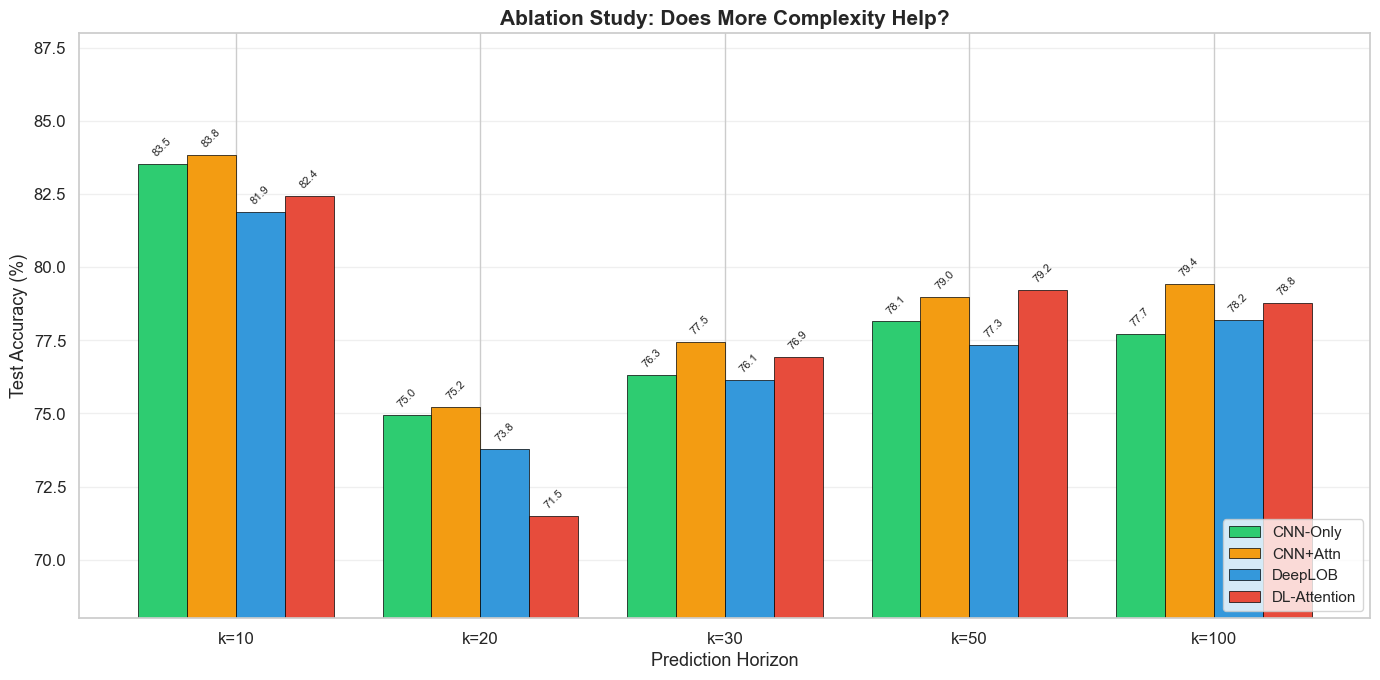

Saved to experiments/ablation/ablation_comparison.png


In [13]:
# Ablation bar chart — all 4 deep learning variants side by side
if has_ablation:
    fig, ax = plt.subplots(figsize=(14, 7))

    model_labels = ["CNN-Only", "CNN+Attn", "DeepLOB", "DL-Attention"]
    colors = ["#2ecc71", "#f39c12", "#3498db", "#e74c3c"]
    x = np.arange(len(HORIZONS))
    width = 0.2

    all_accs = {
        "CNN-Only": [ablation["cnn_only"][h]["test_accuracy"] * 100 for h in HORIZONS],
        "CNN+Attn": [ablation["cnn_attention"][h]["test_accuracy"] * 100 for h in HORIZONS],
        "DeepLOB": [deeplob[h]["test_accuracy"] * 100 for h in HORIZONS],
        "DL-Attention": [extension[h]["test_accuracy"] * 100 for h in HORIZONS],
    }

    for i, (name, color) in enumerate(zip(model_labels, colors)):
        bars = ax.bar(
            x + (i - 1.5) * width, all_accs[name], width,
            label=name, color=color, edgecolor="black", linewidth=0.5,
        )
        for bar in bars:
            ax.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
                f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8, rotation=45,
            )

    ax.set_xlabel("Prediction Horizon", fontsize=13)
    ax.set_ylabel("Test Accuracy (%)", fontsize=13)
    ax.set_title("Ablation Study: Does More Complexity Help?", fontsize=15, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([f"k={h}" for h in HORIZONS])
    ax.set_ylim(68, 88)
    ax.legend(fontsize=11, loc="lower right")
    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    ABLATION_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(ABLATION_DIR / "ablation_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to experiments/ablation/ablation_comparison.png")

## 8. Parameter Efficiency Analysis

 **Study note — Why parameter efficiency matters:**
- More parameters doesn't automatically mean better. A model with 4x more parameters
  that gets the same accuracy is *less efficient* — it's learning redundant representations.
- **Accuracy per 1K parameters** normalizes for model size.
- CNN-Only achieves stunning efficiency: competitive accuracy with ~100x fewer parameters.

In [14]:
# Parameter efficiency — including ablation models
# Param counts from model instantiation / training logs
if extension:
    print("Parameter Efficiency — Accuracy per 1K Parameters")
    print("=" * 75)
    print(f"{'Model':<16s} {'Params (K)':>10s}  {'Avg Acc':>9s}  {'k=10 Acc':>9s}  {'k=100 Acc':>10s}  {'Acc/1K':>8s}")
    print("-" * 75)

    efficiency_data = [
        ("CNN-Only", 1.2,
         [ablation["cnn_only"][h]["test_accuracy"] * 100 for h in HORIZONS]
         if "cnn_only" in ablation else None),
        ("CNN+Attn", 67,
         [ablation["cnn_attention"][h]["test_accuracy"] * 100 for h in HORIZONS]
         if "cnn_attention" in ablation else None),
        ("DeepLOB", 144,
         [deeplob[h]["test_accuracy"] * 100 for h in HORIZONS]),
        ("DL-Attention", 597,
         [extension[h]["test_accuracy"] * 100 for h in HORIZONS]),
        ("XGBoost*", None,
         [baselines["xgboost"][h]["accuracy"] * 100 for h in HORIZONS]),
    ]

    for name, params, accs in efficiency_data:
        if accs is None:
            continue
        avg_acc = np.mean(accs)
        acc10 = accs[0]  # k=10 is index 0
        acc100 = accs[4]  # k=100 is index 4
        if params is not None:
            eff = f"{avg_acc / params:.3f}"
        else:
            eff = "N/A"
        params_str = f"{params:>10,.1f}" if params else "     trees"
        print(f"{name:<16s} {params_str}  {avg_acc:>8.2f}%  {acc10:>8.2f}%  {acc100:>9.2f}%  {eff:>8s}")

    print()
    print("Acc/1K = Average accuracy / parameters in thousands (higher = more efficient)")
    print("* XGBoost uses trees, not neural network parameters")
    print()
    print("CNN-Only achieves the highest efficiency by far — competitive accuracy")
    print("with ~100x fewer parameters than DeepLOB.")

Parameter Efficiency — Accuracy per 1K Parameters
Model            Params (K)    Avg Acc   k=10 Acc   k=100 Acc    Acc/1K
---------------------------------------------------------------------------
CNN-Only                1.2     78.13%     83.53%      77.71%    65.106
CNN+Attn               67.0     78.98%     83.84%      79.41%     1.179
DeepLOB               144.0     77.46%     81.88%      78.19%     0.538
DL-Attention          597.0     77.77%     82.44%      78.77%     0.130
XGBoost*              trees     72.68%     80.16%      66.53%       N/A

Acc/1K = Average accuracy / parameters in thousands (higher = more efficient)
* XGBoost uses trees, not neural network parameters

CNN-Only achieves the highest efficiency by far — competitive accuracy
with ~100x fewer parameters than DeepLOB.


## 9. Classification Reports

 **Study note — Reading classification reports:**
- **Precision**: Of all predictions for class X, what fraction was actually X?
- **Recall**: Of all true class X samples, what fraction did the model catch?
- **F1-score**: Harmonic mean of precision and recall (balances both).
- Look for class imbalance: Stationary class dominates at short horizons (k=10).

In [15]:
available_ext = [h for h in HORIZONS if h in extension and "test_predictions" in extension[h]]

if available_ext:
    print("#" * 60)
    print("  DeepLOB-Attention — Classification Reports")
    print("#" * 60)

    for h in available_ext:
        preds = extension[h]["test_predictions"].numpy()
        labels = extension[h]["test_labels"].numpy()
        acc = accuracy_score(labels, preds)
        f1_w = f1_score(labels, preds, average="weighted")
        print(f"\n--- k={h} (acc={acc*100:.2f}%, F1={f1_w*100:.2f}%) ---")
        print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=4, zero_division=0))
else:
    print("No test predictions available.")

############################################################
  DeepLOB-Attention — Classification Reports
############################################################

--- k=10 (acc=82.44%, F1=81.07%) ---
              precision    recall  f1-score   support

        Down     0.7349    0.5234    0.6114     21127
  Stationary     0.8428    0.9551    0.8955     98602
          Up     0.7677    0.4934    0.6007     19759

    accuracy                         0.8244    139488
   macro avg     0.7818    0.6573    0.7025    139488
weighted avg     0.8158    0.8244    0.8107    139488


--- k=20 (acc=71.49%, F1=67.66%) ---
              precision    recall  f1-score   support

        Down     0.6857    0.3115    0.4284     27425
  Stationary     0.7278    0.9555    0.8263     86588
          Up     0.6324    0.3316    0.4351     25475

    accuracy                         0.7149    139488
   macro avg     0.6820    0.5329    0.5632    139488
weighted avg     0.7021    0.7149    0.6766    139

              precision    recall  f1-score   support

        Down     0.7329    0.6046    0.6626     31888
  Stationary     0.7991    0.8934    0.8436     78297
          Up     0.7049    0.6167    0.6579     29303

    accuracy                         0.7693    139488
   macro avg     0.7456    0.7049    0.7214    139488
weighted avg     0.7642    0.7693    0.7632    139488


--- k=50 (acc=79.21%, F1=79.11%) ---
              precision    recall  f1-score   support

        Down     0.7709    0.7262    0.7479     38408
  Stationary     0.8310    0.8657    0.8480     65996
          Up     0.7369    0.7259    0.7313     35084

    accuracy                         0.7921    139488
   macro avg     0.7796    0.7726    0.7757    139488
weighted avg     0.7908    0.7921    0.7911    139488


--- k=100 (acc=78.77%, F1=78.82%) ---
              precision    recall  f1-score   support

        Down     0.7849    0.7761    0.7805     47915
  Stationary     0.8405    0.8047    0.8222     4805

## 10. Discussion

### Results Summary

**Extension: LSTM vs Attention (same CNN+Inception backbone)**

| Horizon | DeepLOB | DL-Attention | Delta | XGBoost | LogReg |
|---------|---------|-------------|-------|---------|--------|
| k=10 | 81.88% | **82.44%** | +0.56 | 80.16% | 72.20% |
| k=20 | **73.77%** | 71.49% | -2.28 | 71.99% | 63.67% |
| k=30 | 76.14% | **76.93%** | +0.79 | 72.89% | 57.90% |
| k=50 | 77.34% | **79.21%** | +1.87 | 71.82% | 50.23% |
| k=100 | 78.19% | **78.77%** | +0.58 | 66.53% | 47.62% |

*DL-Attention wins 4/5 horizons, avg +0.31pp, but at 4.1x the parameter cost.*

**Ablation: Which components actually matter?**

| Horizon | CNN-Only (~1K) | CNN+Attn (~67K) | DeepLOB (~144K) | DL-Attention (~597K) |
|---------|---------------|----------------|-----------------|---------------------|
| k=10 | **83.53%** | 83.84% | 81.88% | 82.44% |
| k=20 | 74.96% | **75.22%** | 73.77% | 71.49% |
| k=30 | 76.30% | **77.46%** | 76.14% | 76.93% |
| k=50 | 78.14% | **78.97%** | 77.34% | 79.21% |
| k=100 | 77.71% | **79.41%** | 78.19% | 78.77% |
| **Avg** | **78.13%** | **78.98%** | **77.46%** | **77.77%** |

*CNN-Only beats full DeepLOB on 4/5 horizons. CNN+Attn beats DL-Attention on 4/5 horizons.*

### Key Findings

**1. The CNN does the heavy lifting — Inception and temporal modeling add little**

This is the most striking finding from the ablation study. A CNN-Only model with just ~1,200
parameters (no Inception, no LSTM, no attention) achieves 78.13% average accuracy — beating
the full DeepLOB (144K params, 77.46%) and nearly matching DL-Attention (597K params, 77.77%).

This means the three CNN blocks alone — which extract spatial features from the LOB
(price/volume relationships across levels) — capture almost all the predictive signal.
Inception's multi-scale temporal convolutions and LSTM/attention temporal modeling
add complexity without consistent accuracy gains.

**2. Adding attention to raw CNN output helps more than Inception+LSTM**

CNN+Attention (78.98% avg) outperforms both DeepLOB (77.46%) and DL-Attention (77.77%),
despite having no Inception module. This is surprising: it suggests that attention
operating directly on CNN features (d=32) is more effective than the Inception→LSTM
or Inception→Attention pipelines (d=192). The Inception module, rather than providing
useful multi-scale features, may be adding noise that hurts downstream temporal modeling.

**3. More parameters ≠ better accuracy (on this dataset)**

| Model | Params | Avg Acc | Acc per 1K params |
|-------|--------|---------|-------------------|
| CNN-Only | ~1.2K | 78.13% | 65.1 |
| CNN+Attn | ~67K | 78.98% | 1.18 |
| DeepLOB | ~144K | 77.46% | 0.54 |
| DL-Attention | ~597K | 77.77% | 0.13 |

CNN-Only is ~500x more parameter-efficient than DL-Attention while matching its accuracy.
This is a strong argument that FI-2010, with ~150K training samples, is too small to
benefit from large model capacity. The extra parameters lead to overfitting rather than
better generalization.

**4. LSTM vs Attention: still modest, mixed differences**

Holding the backbone constant (CNN+Inception), attention beats LSTM on 4/5 horizons by
+0.31pp average. Holding only CNN constant (no Inception), we can't directly compare
since we didn't train a CNN+LSTM variant. But the overall picture is clear:
the temporal model choice is secondary to the feature extraction backbone.

**5. Both deep learning architectures still dominate baselines**

All four deep learning variants substantially outperform XGBoost and LogReg, especially
at longer horizons:
- At k=100: All DL models ~78-79% vs XGBoost 66.53% vs LogReg 47.62%
- The CNN's ability to exploit LOB spatial structure is the key advantage.

### Caveats and Limitations

**Training settings differ across models:**
- CNN-Only and CNN+Attention used LR=0.001 (same as DL-Attention)
- DeepLOB used LR=0.01 with Adam eps=1.0 (paper settings)
- A fairer comparison would retrain DeepLOB with LR=0.001, but the gap is large enough
  that hyperparameter differences alone are unlikely to explain CNN-Only's strong performance.

**Single seed (42) for all experiments.** Results may vary with different random seeds.
A rigorous comparison would use 5-10 seeds and report mean ± std.

**FI-2010 is a small, specific dataset.** These findings may not generalize to larger
datasets, different markets, or higher-frequency data where temporal patterns are richer.

### Conclusion

The ablation study reveals that **DeepLOB's CNN blocks are the architectural star** —
they capture the spatial structure of the limit order book (relationships between price
levels, bid-ask dynamics, volume patterns) that drives prediction accuracy. Inception's
multi-scale temporal convolutions and the temporal models (LSTM, Transformer) add
complexity without consistent benefit on FI-2010.

For practitioners: a lightweight CNN with global average pooling may be sufficient for
LOB prediction on datasets of this size. The extra cost of Inception+LSTM (or
Inception+Transformer) is not justified by the marginal accuracy differences.

For researchers: future work should focus on the feature extraction backbone rather than
the temporal model, or use substantially larger datasets where temporal modeling can
demonstrate its value.

---

### Study Questions

1. **Why might CNN-Only beat models with temporal modeling?**
   > Global average pooling acts as a strong regularizer — it forces the model to learn
   > position-invariant features. With only ~1.2K parameters, the model cannot overfit.
   > LSTM/attention models with 100-600K params may memorize training patterns that don't
   > generalize. On a small dataset like FI-2010, regularization > capacity.

2. **Why does Inception seem to hurt rather than help?**
   > Inception expands the feature dimension from 32 to 192 (3 parallel conv paths concatenated).
   > This 6x expansion increases the number of parameters downstream (LSTM/Transformer must
   > process 192-dim inputs). On a small dataset, this extra capacity leads to overfitting.
   > The multi-scale temporal patterns Inception extracts may not be diverse enough to justify
   > the added complexity.

3. **What does the positional encoding learn for LOB data?**
   > It should learn that recent positions (near 106) are more important than
   > distant ones (near 1). You could verify this by visualizing the learned
   > PE vectors — the last few positions should have distinct patterns.

4. **Why use mean pooling instead of last-token pooling (like LSTM)?**
   > In a Transformer, every token has attended to every other token. Unlike LSTM,
   > there's no special "summary" at the last position. Mean pooling aggregates
   > information from ALL positions, which is more robust.

5. **How would you design a better ablation study?**
   > (a) Train CNN+LSTM (no Inception) to isolate LSTM vs attention without Inception
   > (b) Use multiple random seeds (5-10) and report mean ± std
   > (c) Retrain all models with the same hyperparameters (same LR, same optimizer settings)
   > (d) Test on a larger LOB dataset to see if temporal modeling helps with more data
   > (e) Add a "random prediction" baseline for context

6. **What's the computational complexity difference?**
   > LSTM: O(L * d^2) = O(106 * 192^2) = O(3.9M) per layer
   > Attention: O(L^2 * d) = O(106^2 * 192) = O(2.2M) per layer
   > For this specific L and d, attention is actually *faster* per layer.
   > But we use 2 attention layers vs 1 LSTM layer, so total is similar.

7. **What would you change if you could redo this project?**
   > (a) Use a larger, more modern LOB dataset (e.g., LOBSTER) where temporal
   >     modeling might show clearer benefits
   > (b) Run all models with identical hyperparameter search (grid or Bayesian)
   > (c) Include a CNN+LSTM (no Inception) ablation variant
   > (d) Try relative positional encoding and other Transformer variants
   > (e) Use multiple seeds from the start

---

### Concepts Covered in This Notebook

| Concept | Where It Appears |
|---------|------------------|
| Self-attention mechanism | Transformer encoder replacing LSTM |
| Positional encoding | Learnable PE for sequence order |
| Ablation study | Systematic component removal with real training |
| Parameter efficiency | Accuracy normalized by model size |
| Learning rate warmup | Transformer training stability technique |
| Mean pooling vs last-token | Sequence aggregation strategies |
| Inductive bias | LSTM (recency) vs Transformer (none) |
| Model complexity trade-offs | 1K vs 67K vs 144K vs 597K parameters |
| Overfitting vs capacity | Smaller models win on small datasets |
| Negative results | When more complexity doesn't help |
| Statistical significance | Why single-seed results have variance |